# Эксперимент 02: Обучение и оценка моделей

## Цель
Обучить и сравнить модели разной сложности, выбрать лучшую для продакшена.

## Модели
- **Baseline**: Logistic Regression — простая интерпретируемая модель
- **Improved**: CatBoost — градиентный бустинг, state-of-the-art для табличных данных

## Метрики
- Accuracy — общая точность
- F1-score — баланс precision и recall
- ROC-AUC — качество ранжирования

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from catboost import CatBoostClassifier
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)

print("Библиотеки импортированы")

Библиотеки импортированы


In [2]:
df = pd.read_csv("../data/processed/employee_burnout_processed.csv")

feature_columns = [
    "gender", "company_type", "wfh_setup_available", "designation",
    "resource_allocation", "mental_fatigue_score", "tenure_months",
    "fatigue_resource_ratio", "is_senior", "high_workload"
]

X = df[feature_columns]
y = df["burnout_target"]

print(f"Признаки: {X.shape[1]}, Строк: {X.shape[0]}")
print(f"Распределение классов:\n{y.value_counts()}")

Признаки: 10, Строк: 22750
Распределение классов:
burnout_target
0    14150
1     8600
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test: {X_test.shape[0]} строк")

Train: 18200 строк
Test: 4550 строк


In [4]:
results = []

print("Обучение Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "F1-score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_proba_lr)
})

print(f"  Accuracy: {results[0]['Accuracy']:.4f}")
print(f"  F1-score: {results[0]['F1-score']:.4f}")
print(f"  ROC-AUC: {results[0]['ROC-AUC']:.4f}")

Обучение Logistic Regression...
  Accuracy: 0.9141
  F1-score: 0.8848
  ROC-AUC: 0.9690


In [5]:
print("Обучение CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    verbose=False,
    random_seed=42
)

catboost_model.fit(X_train, y_train)

y_pred_cb = catboost_model.predict(X_test)
y_proba_cb = catboost_model.predict_proba(X_test)[:, 1]

results.append({
    "Model": "CatBoost",
    "Accuracy": accuracy_score(y_test, y_pred_cb),
    "F1-score": f1_score(y_test, y_pred_cb),
    "ROC-AUC": roc_auc_score(y_test, y_proba_cb)
})

print(f"  Accuracy: {results[1]['Accuracy']:.4f}")
print(f"  F1-score: {results[1]['F1-score']:.4f}")
print(f"  ROC-AUC: {results[1]['ROC-AUC']:.4f}")

Обучение CatBoost...
  Accuracy: 0.9204
  F1-score: 0.8954
  ROC-AUC: 0.9727


Сравнение моделей:


,Accuracy,F1-score,ROC-AUC
Model,,,
Logistic Regression,0.9141,0.8848,0.9690
CatBoost,0.9204,0.8954,0.9727


<Figure size 1000x600 with 0 Axes>

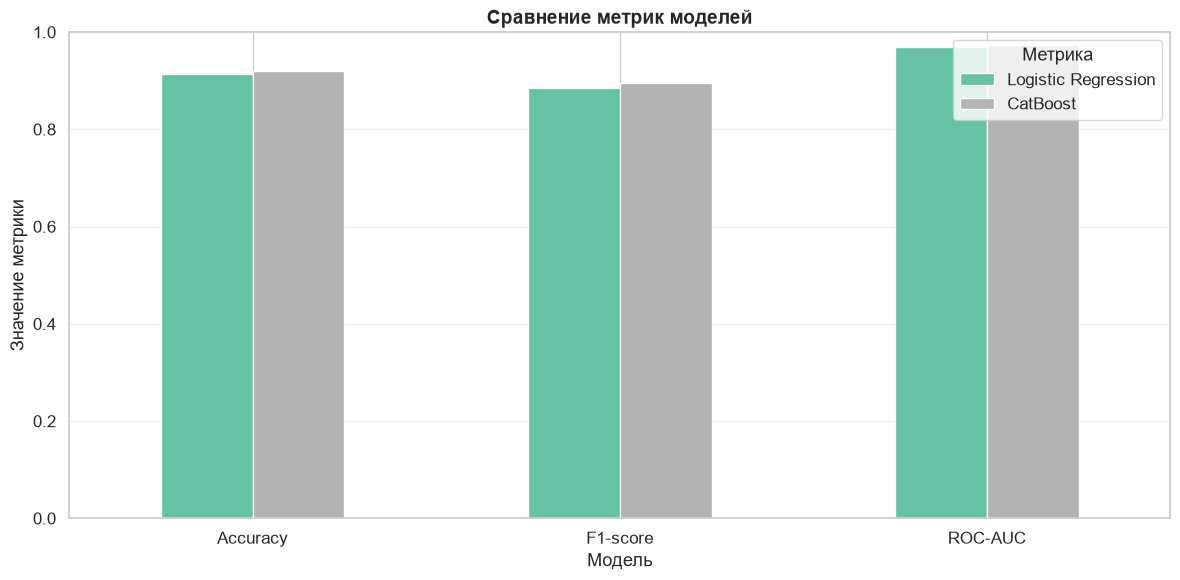

In [6]:
results_df = pd.DataFrame(results).set_index("Model")

print("Сравнение моделей:")
display(results_df.round(4))

plt.figure(figsize=(10, 6))
results_df.T.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Сравнение метрик моделей', fontsize=14, fontweight='bold')
plt.ylabel('Значение метрики')
plt.xlabel('Модель')
plt.xticks(rotation=0)
plt.ylim([0, 1])
plt.legend(title='Метрика')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
best_model_name = results_df["ROC-AUC"].idxmax()
print(f"Лучшая модель по ROC-AUC: {best_model_name}")

best_model = catboost_model if best_model_name == "CatBoost" else lr_model

Лучшая модель по ROC-AUC: CatBoost


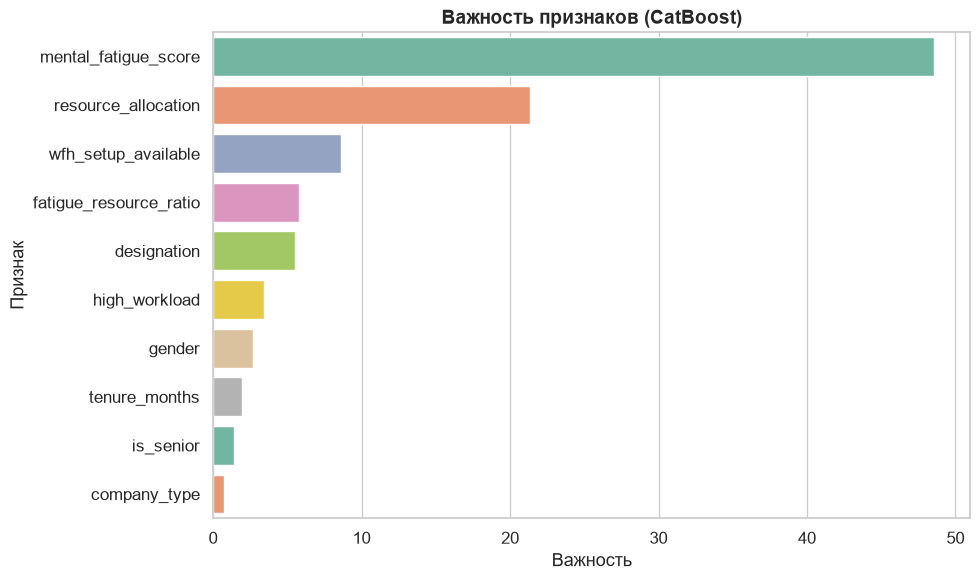

Топ-5 важных признаков:
                  feature  importance
5    mental_fatigue_score   48.578961
4     resource_allocation   21.344448
2     wfh_setup_available    8.619532
7  fatigue_resource_ratio    5.754545
3             designation    5.483618


In [8]:
importances = best_model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='Set2')
plt.title('Важность признаков (CatBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

print("Топ-5 важных признаков:")
print(feature_importance_df.head())

In [9]:
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(best_model, "../artifacts/model.pkl")
joblib.dump(feature_columns, "../artifacts/feature_columns.pkl")

print("Модели сохранены в artifacts/:")
print("  - model.pkl")
print("  - feature_columns.pkl")

Модели сохранены в artifacts/:
  - model.pkl
  - feature_columns.pkl


## Итоги обучения

### Сравнение моделей
- Logistic Regression (Baseline): ROC-AUC = 0.9690
- CatBoost (Improved): ROC-AUC = 0.9727

### Лучшие признаки
1. `mental_fatigue_score` — ментальная усталость
2. `resource_allocation` — объем нагрузки
3. `wfh_setup_available` — доступность удаленной работы

### Вывод
CatBoost выбран как финальная модель для API благодаря высокой точности и встроенной интерпретируемости.